# <span style="color:red"> Lecture 18 - Time Data </span>

<font size = "4">

In this class we will ...

- Process time series data in Python and Pandas
- Introduce new datatype for time
- Plot multiple series
- Compute growth rates

First, let's import the libraries we'll need, and load in the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# FRED data 
df_financial = pd.read_csv("data_raw/financial.csv")

<font size = "4">

The data can be downloaded from [FRED (Federal Reserve Bank of St. Louis)](https://fred.stlouisfed.org/categories/32255)

Let's inspect the data, and its dtypes:

In [2]:
display(df_financial.head())
print()
display(df_financial.dtypes)

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3
0,4/4/2018,2644.69,24264.30,April 04 2018,"Wednesday, 2018-04-04",4-Apr-18
1,4/5/2018,2662.84,24505.22,April 05 2018,"Thursday, 2018-04-05",5-Apr-18
2,4/6/2018,2604.47,23932.76,April 06 2018,"Friday, 2018-04-06",6-Apr-18
3,4/9/2018,2613.16,23979.10,April 09 2018,"Monday, 2018-04-09",9-Apr-18
4,4/10/2018,2656.87,24408.00,April 10 2018,"Tuesday, 2018-04-10",10-Apr-18


date_str     object
sp500       float64
djia        float64
date_ex1     object
date_ex2     object
date_ex3     object
dtype: object

<font size = "4">

The columns represent:

- First column: date (month, day, year)
- Second column: the S&P 500 stock market index
- Third column: the Dow Jones Industrial Average stock market index
- Columns 4, 5, 6: Other representations of the date. We will discuss them next lecture

<font size = "4">

Notice that the data is ordered from oldest to newest:

In [3]:
print(df_financial["date_str"].iloc[0])
print(df_financial["date_str"].iloc[1])
print("...")
print(df_financial["date_str"].iloc[-2])
print(df_financial["date_str"].iloc[-1])

4/4/2018
4/5/2018
...
4/3/2023
4/4/2023


<font size = "4">

**Question:** What if I want the data arranged in the other order (newest first)? How can I use ``.sort_values()`` to re-order the data?

In [4]:
# Use .sort_values() to sort data newest to oldest
df_financial = df_financial.sort_values(by="date_str", ascending=False)
display(df_financial.head())

# This approach uses alphabetical order, which is incorrect for dates

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3
1157,9/9/2022,4067.36,32151.71,September 09 2022,"Friday, 2022-09-09",9-Sep-22
896,9/9/2021,4493.28,34879.38,September 09 2021,"Thursday, 2021-09-09",9-Sep-21
635,9/9/2020,3398.96,27940.47,September 09 2020,"Wednesday, 2020-09-09",9-Sep-20
373,9/9/2019,2978.43,26835.51,September 09 2019,"Monday, 2019-09-09",9-Sep-19
1156,9/8/2022,4006.18,31774.52,September 08 2022,"Thursday, 2022-09-08",8-Sep-22


<font size = "4">

If you try to sort dates that are represented by *strings*, they will be sorted "lexicographically" (alphabetically).

The strings representing the dates must be converted to a new datatype, the ``datetime`` format.

This can be done with the Pandas function ``to_datetime``

In [5]:
# Use the Pandas datetime to convert the column to datetime format 
# We'll add a new column to the DataFrame
df_financial["date"] = pd.to_datetime(df_financial["date_str"])
display(df_financial.head())

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3,date
1157,9/9/2022,4067.36,32151.71,September 09 2022,"Friday, 2022-09-09",9-Sep-22,2022-09-09
896,9/9/2021,4493.28,34879.38,September 09 2021,"Thursday, 2021-09-09",9-Sep-21,2021-09-09
635,9/9/2020,3398.96,27940.47,September 09 2020,"Wednesday, 2020-09-09",9-Sep-20,2020-09-09
373,9/9/2019,2978.43,26835.51,September 09 2019,"Monday, 2019-09-09",9-Sep-19,2019-09-09
1156,9/8/2022,4006.18,31774.52,September 08 2022,"Thursday, 2022-09-08",8-Sep-22,2022-09-08


<font size = "4">

Let's check the DataTypes again

In [6]:
display(df_financial.dtypes)

date_str            object
sp500              float64
djia               float64
date_ex1            object
date_ex2            object
date_ex3            object
date        datetime64[ns]
dtype: object

<font size = "4">

Compare with the types of the column elements:

In [7]:
print(type(df_financial['date_str'].iloc[0]))
print(type(df_financial['sp500'].iloc[0]))
print(type(df_financial['date'].iloc[0])) 

<class 'str'>
<class 'numpy.float64'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


<font size = "4">

- So the "date" column has the datatype ``datetime64[ns]``, but its elements are Pandas ``Timestamp`` objects.

- There is a difference between how Pandas stores data "internally" and when you extract parts of the data.

- We've actually seen this before. Note that the "date_str" column has the datatype ``object``, but its elements are ``str`` (strings).

Regardless, now that we have converted the dates to an appropriate datatype, we can now sort them sensibly!

In [8]:
# sort df_financial by the "date" column
df_financial = df_financial.sort_values(by="date", ascending=False)
display(df_financial.head())

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3,date
1304,4/4/2023,4100.60,33402.38,April 04 2023,"Tuesday, 2023-04-04",4-Apr-23,2023-04-04
1303,4/3/2023,4124.51,33601.15,April 03 2023,"Monday, 2023-04-03",3-Apr-23,2023-04-03
1302,3/31/2023,4109.31,33274.15,March 31 2023,"Friday, 2023-03-31",31-Mar-23,2023-03-31
1301,3/30/2023,4050.83,32859.03,March 30 2023,"Thursday, 2023-03-30",30-Mar-23,2023-03-30
1300,3/29/2023,4027.81,32717.60,March 29 2023,"Wednesday, 2023-03-29",29-Mar-23,2023-03-29


<font size = "4">

How can I plot time vs. the S&P 500 index?

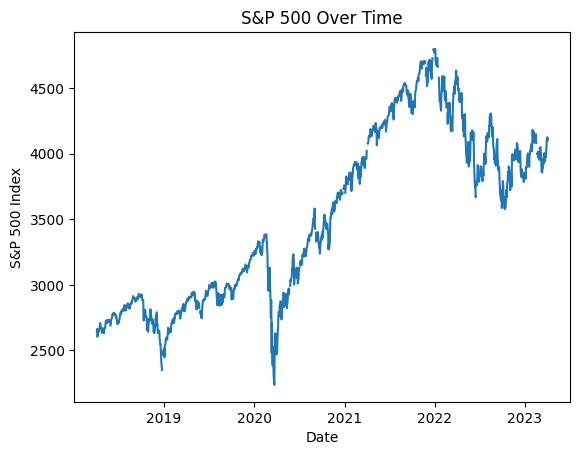

In [9]:
# Goal: plot date (x-axis) vs. S&P 500 (y-axis)
x_vals = df_financial["date"]
y_vals = df_financial["sp500"]
plt.plot(x_vals, y_vals)

# label x-axis
plt.xlabel("Date")
# label y-axis
plt.ylabel("S&P 500 Index")
# title
plt.title("S&P 500 Over Time")
# show plot
plt.show()


<font size = "4">

So there's another advantage of converting to ``datetime`` objects...plots look much better!

**Note**: ``matplotlib.pyplot.plot`` has compatibility with Pandas DataFrames:

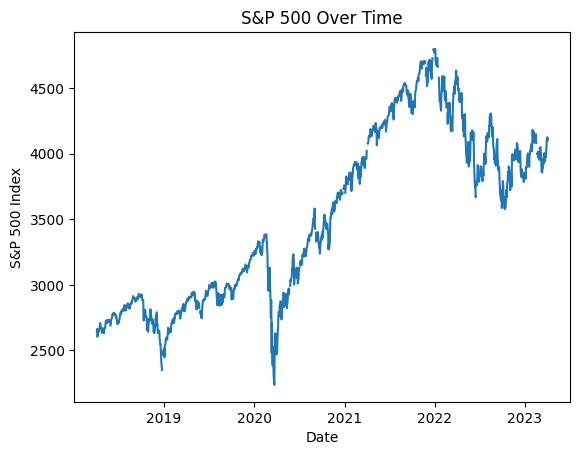

In [10]:
# Goal: plot date (x-axis) vs. S&P 500 (y-axis)
x_vals = "date"
y_vals = "sp500"
plt.plot(x_vals, y_vals, data=df_financial)

# label x-axis
plt.xlabel("Date")
# label y-axis
plt.ylabel("S&P 500 Index")
# title
plt.title("S&P 500 Over Time")
# show plot
plt.show()


<font size = "4">

**Important:** Whatever variable you put on the x-axis, the data better be sorted by that variable!!

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3,date
513,3/23/2020,2237.40,18591.93,March 23 2020,"Monday, 2020-03-23",23-Mar-20,2020-03-23
512,3/20/2020,2304.92,19173.98,March 20 2020,"Friday, 2020-03-20",20-Mar-20,2020-03-20
188,12/24/2018,2351.10,21792.20,December 24 2018,"Monday, 2018-12-24",24-Dec-18,2018-12-24
508,3/16/2020,2386.13,20188.52,March 16 2020,"Monday, 2020-03-16",16-Mar-20,2020-03-16
510,3/18/2020,2398.10,19898.92,March 18 2020,"Wednesday, 2020-03-18",18-Mar-20,2020-03-18
...,...,...,...,...,...,...,...
175,12/5/2018,NaN,NaN,December 05 2018,"Wednesday, 2018-12-05",5-Dec-18,2018-12-05
166,11/22/2018,NaN,NaN,November 22 2018,"Thursday, 2018-11-22",22-Nov-18,2018-11-22
108,9/3/2018,NaN,NaN,September 03 2018,"Monday, 2018-09-03",3-Sep-18,2018-09-03
65,7/4/2018,NaN,NaN,July 04 2018,"Wednesday, 2018-07-04",4-Jul-18,2018-07-04


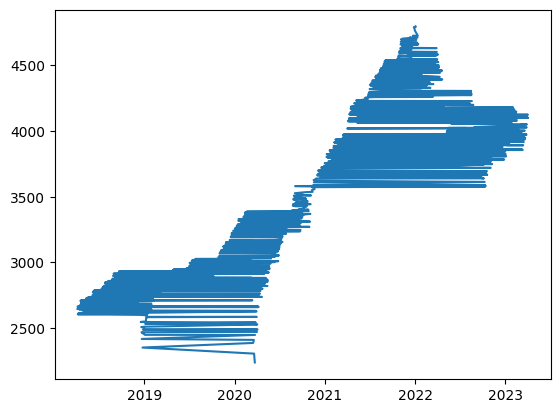

In [11]:
df_sorted = df_financial.sort_values(by = "sp500")
display(df_sorted)

# try plotting date vs. sp500 for df_sorted
plt.plot("date", "sp500", data=df_sorted)


<font size = "4">

**Exercise:**

How would I generate a plot of time vs. Dow Jones Industrial Average?

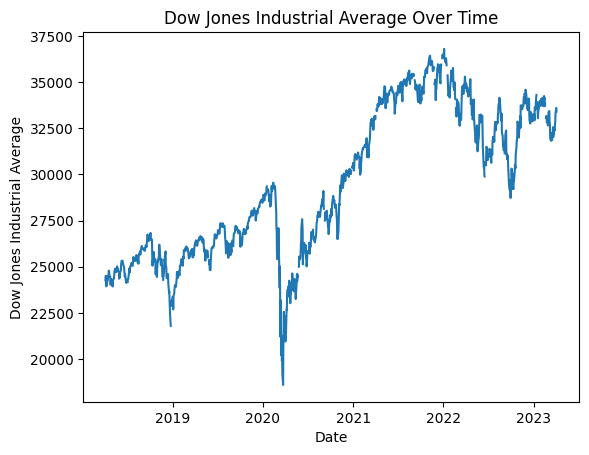

In [12]:
# Write your own code
x_vals = "date"
y_vals = "djia"
plt.plot(x_vals, y_vals, data=df_financial)
# label x-axis
plt.xlabel("Date")
# label y-axis
plt.ylabel("Dow Jones Industrial Average")
# title
plt.title("Dow Jones Industrial Average Over Time")
# show plot
plt.show()


<font size = "4">

- How do we plot multiple columns of the dataset? 
- For instance, let's plot both time vs. S&P 500 and time vs. Dow Jones
- Each DataFrame has its own ``.plot`` method.

In [13]:
# Step 1 of chain:
# Grab columns we want to plot
display(df_financial[["date", "sp500", "djia"]].head())

# For instance, let's plot both time vs. S&P 500 and time vs. Dow Jones

,date,sp500,djia
1304,2023-04-04,4100.60,33402.38
1303,2023-04-03,4124.51,33601.15
1302,2023-03-31,4109.31,33274.15
1301,2023-03-30,4050.83,32859.03
1300,2023-03-29,4027.81,32717.60


In [14]:
# Step 2 of chain:
# We will plot the date on the x-axis.
# So we will make "date" the index column

display(df_financial[["date", "sp500", "djia"]].set_index("date").head())

,sp500,djia
date,,
2023-04-04,4100.60,33402.38
2023-04-03,4124.51,33601.15
2023-03-31,4109.31,33274.15
2023-03-30,4050.83,32859.03
2023-03-29,4027.81,32717.60


<Axes: xlabel='date'>

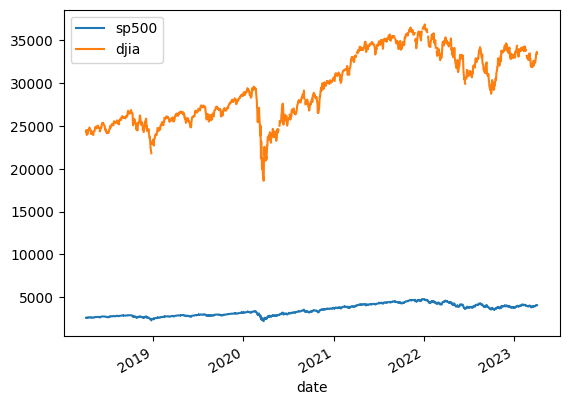

In [15]:
# Step 3 of chain:
# We will use the DataFrame's .plot method.
# This will plot index vs. column 1 AND
# will plot index vs. column 2

df_financial[["date","sp500","djia"]].set_index("date").plot()
# Return value: axes object 

[]

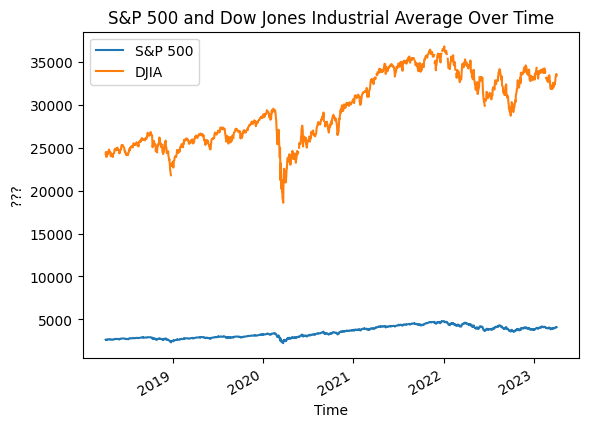

In [16]:
# .plot() used column names for the legend and x-axis.
# Here's how to adjust them ourselves

ax = df_financial[["date","sp500","djia"]].set_index("date").plot()
ax.set_xlabel("Time")
ax.set_ylabel("???") # The y-axis is different for both index
ax.legend(["S&P 500", "DJIA"])
ax.set_title("S&P 500 and Dow Jones Industrial Average Over Time")
ax.plot()

<font size = "4">

The S&P 500 and Dow Jones have different units. Should either:

- Convert one to the other's units
- Have a left and right y-axis, one for each variable (more on this in a future lecture).
- Plot a "unitless" or "non-dimensional" measure of both.

The **percentage growth** is a non-dimensional quantity we can calculate for both:

$$\textrm{per. growth} = \frac{(\textrm{today's index}) - (\textrm{yesterday's index})}{\textrm{yesterdays's index}} \times 100\  \%$$

In [17]:
# Let's calculate the numerator: the difference between today's index 
# and yesterday's index.

df_financial["diff_sp500"] = df_financial["sp500"].diff()
display(df_financial.head())

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3,date,diff_sp500
1304,4/4/2023,4100.60,33402.38,April 04 2023,"Tuesday, 2023-04-04",4-Apr-23,2023-04-04,NaN
1303,4/3/2023,4124.51,33601.15,April 03 2023,"Monday, 2023-04-03",3-Apr-23,2023-04-03,23.91
1302,3/31/2023,4109.31,33274.15,March 31 2023,"Friday, 2023-03-31",31-Mar-23,2023-03-31,-15.20
1301,3/30/2023,4050.83,32859.03,March 30 2023,"Thursday, 2023-03-30",30-Mar-23,2023-03-30,-58.48
1300,3/29/2023,4027.81,32717.60,March 29 2023,"Wednesday, 2023-03-29",29-Mar-23,2023-03-29,-23.02


<font size = "4">

To easily divide by "yesterday's index", we will shift the "sp500" column down, and make it a new column

In [18]:
# Let's make the denominator: "yesterday's index"
# Also known as the "lag"

# ".shift(1)" computes a new column with the value of "sp500"
# one period before. By convention the first column is assigned
# a missing value

df_financial["lag_sp500"] = df_financial["sp500"].shift(1)

display(df_financial[["date", "sp500", "diff_sp500", "lag_sp500"]].head())

,date,sp500,diff_sp500,lag_sp500
1304,2023-04-04,4100.60,NaN,NaN
1303,2023-04-03,4124.51,23.91,4100.60
1302,2023-03-31,4109.31,-15.20,4124.51
1301,2023-03-30,4050.83,-58.48,4109.31
1300,2023-03-29,4027.81,-23.02,4050.83


In [19]:
# Now we combine ".diff()" and ".shift()" to compute growth rates
df_financial["growth_sp500"] = df_financial["diff_sp500"] / df_financial["lag_sp500"] * 100

<font size = "4">

Now, we plot the growth rate:

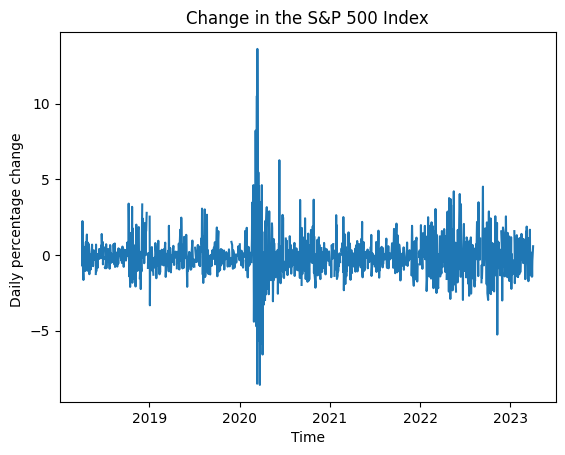

In [ ]:
# Plot the growth rates over time
plt.plot("date", "growth_sp500",
          data = df_financial)
plt.xlabel("Time")
plt.ylabel("Daily percentage change ")
plt.title("Change in the S&P 500 Index")
plt.show()

<font size = "4" >

**Exercise**

- Compute a column with the growth of the Dow Jones
- Plot the growth of the S&P 500 and Dow Jones in a <br>
single plot

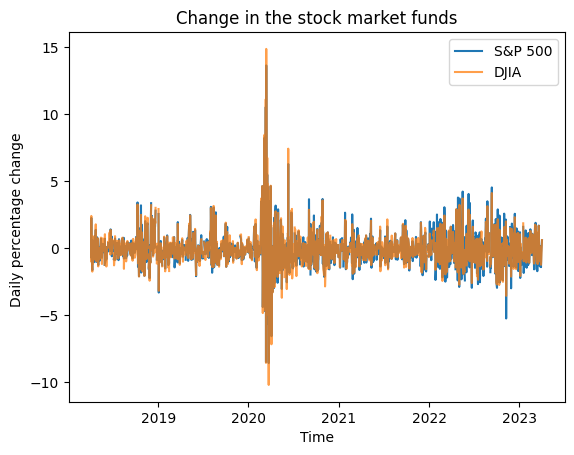

In [31]:
# Write your own code

df_financial["growth_djia"] = (df_financial["djia"].diff() / df_financial["djia"].shift(1) )* 100

plt.plot("date", "growth_sp500",
          data = df_financial)
plt.plot("date", "growth_djia",
          data = df_financial,alpha = 0.75)
plt.xlabel("Time")
plt.ylabel("Daily percentage change ")
plt.title("Change in the stock market funds")
plt.legend(["S&P 500", "DJIA"])
plt.show()

# <span style="color:red"> III. Subsets of time-series data </span>

<font size = "4" >

Like other DataFrames, we can use ``.query()`` to extract subsets of time-series data. Since we have converted to the "Datetime" datatype, logical conditions can be used in a straightforward way. 

In [32]:
# Since the "date" column has a time format, Python
# will interpret "2019-01-01" as a date inside the query command

subset_before  = df_financial.query('date <= "2019-01-01" ')
subset_after   = df_financial.query('date >= "2019-01-01" ')

display(subset_after)

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3,date,diff_sp500,lag_sp500,growth_sp500,growth_djia,covid_period
1304,4/4/2023,4100.60,33402.38,April 04 2023,"Tuesday, 2023-04-04",4-Apr-23,2023-04-04,NaN,NaN,NaN,NaN,False
1303,4/3/2023,4124.51,33601.15,April 03 2023,"Monday, 2023-04-03",3-Apr-23,2023-04-03,23.91,4100.60,0.583085,0.595077,False
1302,3/31/2023,4109.31,33274.15,March 31 2023,"Friday, 2023-03-31",31-Mar-23,2023-03-31,-15.20,4124.51,-0.368529,-0.973181,False
1301,3/30/2023,4050.83,32859.03,March 30 2023,"Thursday, 2023-03-30",30-Mar-23,2023-03-30,-58.48,4109.31,-1.423110,-1.247575,False
1300,3/29/2023,4027.81,32717.60,March 29 2023,"Wednesday, 2023-03-29",29-Mar-23,2023-03-29,-23.02,4050.83,-0.568279,-0.430414,False
...,...,...,...,...,...,...,...,...,...,...,...,...
198,1/7/2019,2549.69,23531.35,January 07 2019,"Monday, 2019-01-07",7-Jan-19,2019-01-07,-24.72,2574.41,-0.960220,-1.076618,False
197,1/4/2019,2531.94,23433.16,January 04 2019,"Friday, 2019-01-04",4-Jan-19,2019-01-04,-17.75,2549.69,-0.696163,-0.417273,False
196,1/3/2019,2447.89,22686.22,January 03 2019,"Thursday, 2019-01-03",3-Jan-19,2019-01-03,-84.05,2531.94,-3.319589,-3.187534,False
195,1/2/2019,2510.03,23346.24,January 02 2019,"Wednesday, 2019-01-02",2-Jan-19,2019-01-02,62.14,2447.89,2.538513,2.909343,False


<font size = "4">

Here are some other subsets we might be interested in:

In [33]:
# Beginning of Covid pandemic (independent of data)
subset_between = df_financial.query("'2020-03-01' <= date <= '2020-05-01'")

# large changes in percentage growth (positive or negative)
subset_large_change = df_financial.query("growth_sp500 > 5 or growth_sp500 < -5")
display(subset_large_change)

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3,date,diff_sp500,lag_sp500,growth_sp500,growth_djia,covid_period
1200,11/9/2022,3748.57,32513.94,November 09 2022,"Wednesday, 2022-11-09",9-Nov-22,2022-11-09,-207.80,3956.37,-5.252289,-3.563449,False
570,6/10/2020,3190.14,26989.99,June 10 2020,"Wednesday, 2020-06-10",10-Jun-20,2020-06-10,188.04,3002.10,6.263615,7.409294,False
522,4/3/2020,2488.65,21052.53,April 03 2020,"Friday, 2020-04-03",3-Apr-20,2020-04-03,-175.03,2663.68,-6.570985,-7.175753,True
515,3/25/2020,2475.56,21200.55,March 25 2020,"Wednesday, 2020-03-25",25-Mar-20,2020-03-25,-154.51,2630.07,-5.874749,-5.993304,True
513,3/23/2020,2237.40,18591.93,March 23 2020,"Monday, 2020-03-23",23-Mar-20,2020-03-23,-209.93,2447.33,-8.577920,-10.205212,True
509,3/17/2020,2529.19,21237.38,March 17 2020,"Tuesday, 2020-03-17",17-Mar-20,2020-03-17,131.09,2398.10,5.466411,6.726295,True
508,3/16/2020,2386.13,20188.52,March 16 2020,"Monday, 2020-03-16",16-Mar-20,2020-03-16,-143.06,2529.19,-5.656356,-4.938745,True
507,3/13/2020,2711.02,23185.62,March 13 2020,"Friday, 2020-03-13",13-Mar-20,2020-03-13,324.89,2386.13,13.615771,14.845566,True
506,3/12/2020,2480.64,21200.62,March 12 2020,"Thursday, 2020-03-12",12-Mar-20,2020-03-12,-230.38,2711.02,-8.497909,-8.561341,True
505,3/11/2020,2741.38,23553.22,March 11 2020,"Wednesday, 2020-03-11",11-Mar-20,2020-03-11,260.74,2480.64,10.510997,11.096845,True


In [24]:
# alternate way. 
# Datetime objects have a ".between()" method



In [25]:
# alternate way. 
# (x > 4 or x < -4) is equivalent to |x| > 4



<font size = "4">

Once we have identified an interesting subset of the data, we might want to visualize it within the context of the original time-series. For example, we might want to **highlight** these regions after plotting the entire series.

We can do this using the ``fill_between`` function from the ``matplotlib.pyplot`` library

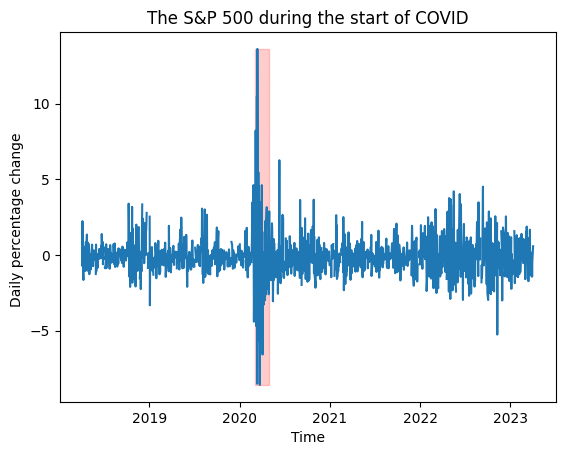

In [26]:
# Create a line plot
plt.plot("date", "growth_sp500", data = df_financial)
plt.xlabel("Time")
plt.ylabel("Daily percentage change ")
plt.title("The S&P 500 during the start of COVID")

# Add a shaded region wth a rectangle
# "x" is the x-coordinates, "y1" and "y2" are the lower
# and upper bounds of the rectangle. We can set this
# to be the minimum and maximum of the outcome.
# we use "where" to test a logical condition

x_vals = df_financial["date"]
y_vals = df_financial["growth_sp500"]
condition = df_financial["date"].between("2020-03-01","2020-05-01")

plt.fill_between(x = x_vals,
                 y1 = y_vals.min(),
                 y2 = y_vals.max(),
                 where = condition,
                 alpha = 0.2,color = "red")


plt.show()

<font size = "4">

- If we want to repeatedly refer to this region of the data, it might be a good idea to add a column to the DataFrame which will indicate which rows are part of the range.

- We can "flag" the data, and add a column of Boolean type to the DataFrame

In [27]:
# Add a column called "covid_period" of Boolean type.
# "True" if date is between March 1st, 2020 and May 1st, 2020
df_financial["covid_period"]  = df_financial["date"].between("2020-03-01","2020-05-01")

display(df_financial.head())
display(df_financial.dtypes)

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3,date,diff_sp500,lag_sp500,growth_sp500,growth_djia,covid_period
1304,4/4/2023,4100.60,33402.38,April 04 2023,"Tuesday, 2023-04-04",4-Apr-23,2023-04-04,NaN,NaN,NaN,NaN,False
1303,4/3/2023,4124.51,33601.15,April 03 2023,"Monday, 2023-04-03",3-Apr-23,2023-04-03,23.91,4100.60,0.583085,0.595077,False
1302,3/31/2023,4109.31,33274.15,March 31 2023,"Friday, 2023-03-31",31-Mar-23,2023-03-31,-15.20,4124.51,-0.368529,-0.973181,False
1301,3/30/2023,4050.83,32859.03,March 30 2023,"Thursday, 2023-03-30",30-Mar-23,2023-03-30,-58.48,4109.31,-1.423110,-1.247575,False
1300,3/29/2023,4027.81,32717.60,March 29 2023,"Wednesday, 2023-03-29",29-Mar-23,2023-03-29,-23.02,4050.83,-0.568279,-0.430414,False


date_str                object
sp500                  float64
djia                   float64
date_ex1                object
date_ex2                object
date_ex3                object
date            datetime64[ns]
diff_sp500             float64
lag_sp500              float64
growth_sp500           float64
growth_djia            float64
covid_period              bool
dtype: object

<font size = "4">

**Exercise**

- Generate a plot of the percentage growth rate of the Dow Jones 
- Highlight regions where there was growth higher than 3\%
or below -3\%

TypeError: float() argument must be a string or a real number, not 'ellipsis'

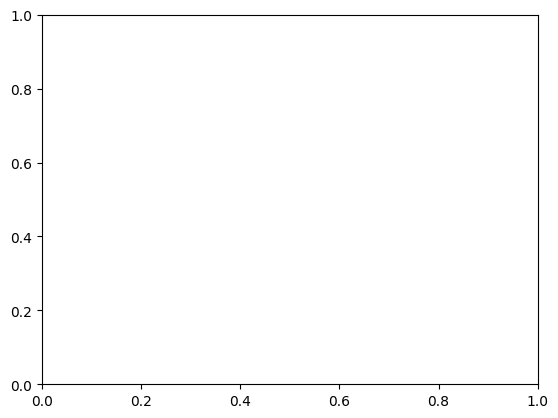

In [ ]:
# Create a line plot
plt.plot(...)


# Add shaded region(s) with plt.fill_between




# show the plot
plt.show()

### Quiz 4 Prep

In [ ]:
# Question 1
import numpy as np
import matplotlib.pyplot as plt

# Correct code cell (already given in the quiz)
x = np.linspace(0, 10, 50)
y = 3*x**2 + 2*x + 5 + np.random.normal(0, 10, size=len(x))
coeffs = np.polyfit(x, y, 2)  # Quadratic model coefficients
model = np.poly1d(coeffs)

# Plot cell – originally incorrect, now fixed
plt.scatter(x, y, label='Data')
plt.plot(x, model(x), color='red', label='Quadratic Fit')  # FIX: should use model(x)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Quadratic Model Fit')
plt.show()


In [ ]:
# Question 2
import pandas as pd

# Read CSV (e.g., 'Delhi_2017.csv')
df = pd.read_csv('Delhi_2017.csv')

# Plot using DataFrame's .plot() method (not plt.plot)
df.plot(x='time', y=['temperature', 'wind_speed'], figsize=(8,5), title='Delhi 2017 Weather')
plt.xlabel('Time')
plt.ylabel('Values')
plt.show()

In [ ]:
# Question 3
import pandas as pd

# Read conversion data (e.g., 'conversion_rates.csv')
df = pd.read_csv('conversion_rates.csv')  # Columns: ['time', 'EUR_USD', 'GBP_USD']

# Compute non-dimensional percentage growth
df['EUR_growth'] = df['EUR_USD'].pct_change() * 100
df['GBP_growth'] = df['GBP_USD'].pct_change() * 100

# Plot both on the same figure
df.plot(x='time', y=['EUR_growth', 'GBP_growth'], title='Percentage Growth in Conversion Rates')
plt.xlabel('Time')
plt.ylabel('Percentage Growth (%)')
plt.legend(['EUR to USD', 'GBP to USD'])
plt.show()

In [ ]:
# Question 4

# Create Boolean column: e.g., check if EUR/USD > 1.15
df['EUR_above_1.15'] = df['EUR_USD'] > 1.15
print(df[['time', 'EUR_USD', 'EUR_above_1.15']].head())

In [ ]:
# Question 5
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df['time'], df['EUR_USD'], label='EUR/USD')
plt.fill_between(df['time'], df['EUR_USD'], where=df['EUR_above_1.15'],
                 color='red', alpha=0.3, label='Above 1.15')
plt.legend()
plt.title('EUR/USD Conversion Rate with Highlighted Regions')
plt.show()

In [ ]:
# Question 6
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
time = np.linspace(0, 2*np.pi, 100)
df = pd.DataFrame({
    'time': time,
    'sin': np.sin(time),
    'cos': np.cos(time)
})

# Compute finite difference derivative
dt = df['time'].diff()
df['d_sin_dt'] = df['sin'].diff() / dt

# Plot cos vs numerical derivative
plt.plot(df['time'], df['cos'], label='cos(t)')
plt.plot(df['time'], df['d_sin_dt'], '--', label='d(sin)/dt')
plt.legend()
plt.title('Comparing cos(t) and d(sin)/dt')
plt.show()